In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.27767328/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

# c1 - First look

Enter measurements for species

In [14]:
logN_dict = {'HI':'14.09, -0.06, +0.06',
            'HeI':'<13.1',
            'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.4',
            'NIII':'<13.0',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            'NeV':'14.17, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',
            'NeVIII':'<13.6',
            'MgX':'<13.6',
            'AlII':'<11.0',
            'AlIII':'<11.4',
            'SiII':'<14.0',
            'SiIII':'<11.7',
            'SiIV':'<12.0',
            'SIV':'<12.9',
            'SV':'<12.6',
            'SVI':'<13.2',
            'FeII':'<11.8',}

Try out a solution

In [15]:
logN_HI_test = 14.08
log_hdens_test = -3.67
log_metals_test = -0.29

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

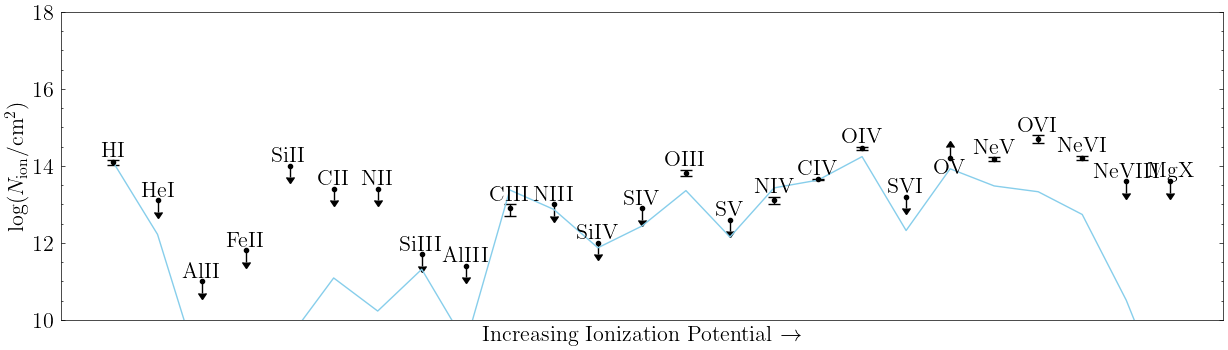

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# c1 - Two-phase solution: low density phase

In [18]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            #'CIII':'12.9, -0.2, +0.1',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'<13.82',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            'NeV':'14.17, -0.05, +0.05',}
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            #'SiII':'<14.0',
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',}
            #'FeII':'<11.8',}

Get column density ratios

In [19]:
gen_logN_ratio_str(logN_dict['OV'], logN_dict['OIV'])

'>-0.25, 0.33'

In [20]:
logN_ratio_dict = {'OV/OIV': '>-0.2, 0.3',
                  'OIII/OIV': '<-0.6, 0.2',
                  'OVI/OIV': '0.2, -0.1, 0.1',}
                  #'NeV/OIV': '-0.28, -0.07, 0.07'}

Generate predicted column density ratios

(-5.0, 2.0)

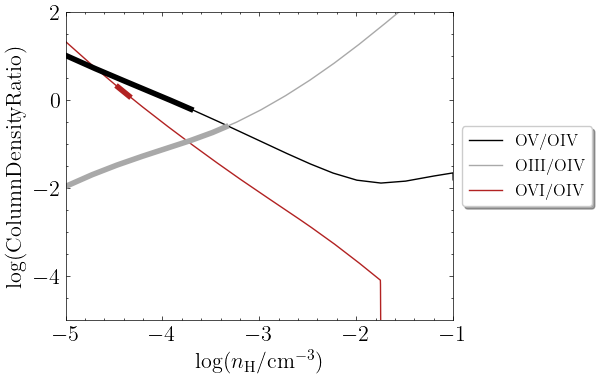

In [21]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1)
ax.set_ylim(-5, 2)

In [22]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [23]:
pos = np.array(-4.3) + 1e-6 * np.random.randn(200, 1)
nwalkers, ndim = pos.shape

In [24]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [25]:
#sampler.run_mcmc(pos, 500, progress=True);

In [26]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo_c1.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c1.csv')

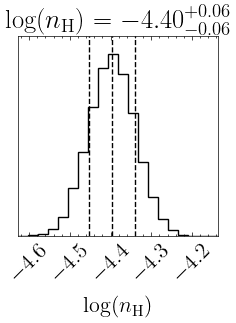

In [27]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [28]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [29]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

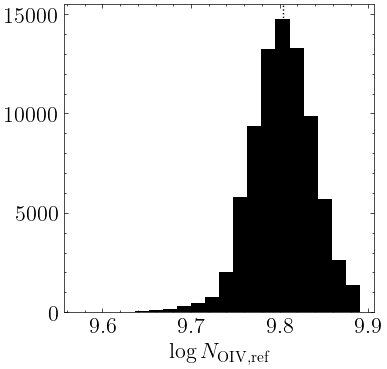

In [30]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

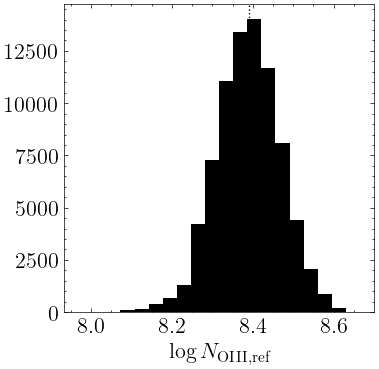

In [31]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

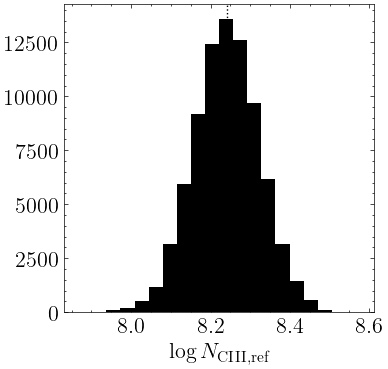

In [32]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [33]:
logN_offset = 14.45-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [34]:
logN_offset

4.646420697622329

Calculate the C/O ratio

In [35]:
logN_CIV_obs = np.random.normal(loc=13.65, scale=0.01, size=len(flat_samples_hdens))

In [36]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [37]:
get_quantiles(C_O_dist)

0.12 -0.03 0.03


Compute N/O ratio

In [38]:
logN_NIV_obs = np.random.normal(loc=13.1, scale=0.1, size=len(flat_samples_hdens))

In [39]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [40]:
get_quantiles(N_O_dist)

-0.52 -0.11 0.11


Get yields

In [41]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.04 -0.08 0.08


In [42]:
get_quantiles(logN_offset+np.median(C_O_dist)+species_logN_interp['O+2'](grid_points_hdens))

13.16 -0.08 0.08


Plot models

In [43]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.4',
            'NIII':'<13.0',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'<13.82',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            'NeV':'14.17, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',}
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            #'SiII':'<14.0',
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [44]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

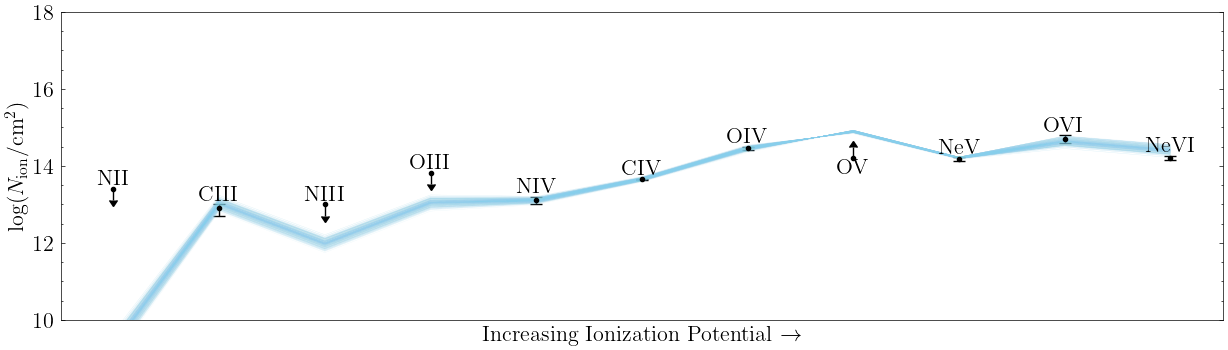

In [45]:
fig, ax = plot_column_densities_obs(logN_dict)

#ax.errorbar(x=1, y=14.06, yerr=[[0.06],[0.04]], color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C': np.median(C_O_dist), 
                                        'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [46]:
logN_OIII_tot = np.random.normal(loc=13.82, scale=0.08, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=13.16, scale=0.08, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

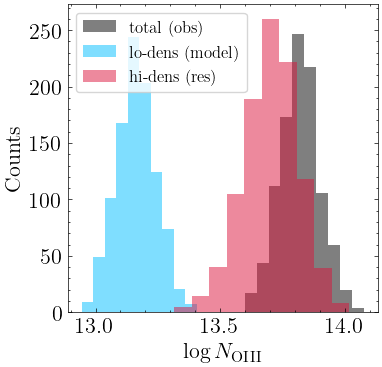

In [47]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [48]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [49]:
get_quantiles(logN_OIII_hi_dens_clean)

13.71 -0.12 0.1


# c1 - Two-phase solution: high density phase

In [50]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            #'CIII':'12.9, -0.2, +0.1',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.7, -0.1, +0.1',
            'OIV':'<14.45',
            #'OV':'>14.2',
            #'OVI':'14.7, -0.1, +0.1',
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            'SiII':'<14.0',}
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',
            #'FeII':'<11.8',}

In [51]:
gen_logN_ratio_str(logN_dict['OIV'], logN_dict['OIII'])

'<0.75, 0.17'

In [52]:
logN_ratio_dict = {'SiII/OIII': '<0.3, 0.2',
                   'OIV/OIII': '<0.7, 0.2'
                  }

(-5.0, 5.0)

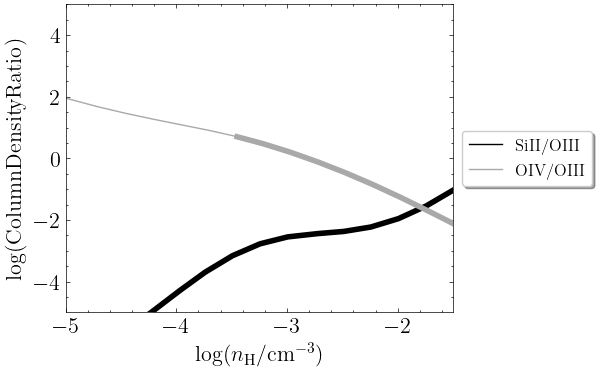

In [53]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [54]:
pos = np.array(-2.5) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [55]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [56]:
#sampler.run_mcmc(pos, 500, progress=True);

In [57]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_hi_c1.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_hi_c1.csv')

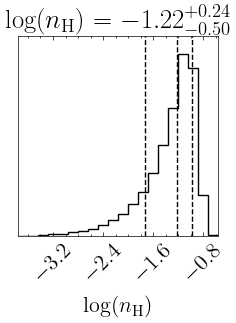

In [58]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [59]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [60]:
logN_offset = 13.7-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [61]:
logN_offset

7.56468093799765

Get yields

Plot models

In [62]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            #'CIII':'12.9, -0.2, +0.1',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.7, -0.1, +0.1',
            'OIV':'<14.45',
            #'OV':'>14.2',
            #'OVI':'14.7, -0.1, +0.1',
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            'SiII':'<14.0',
            'SiIII':'<11.7',
            'SiIV':'<12.0',
            'SIV':'<12.9',
            'SV':'<12.6',}
            #'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [63]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

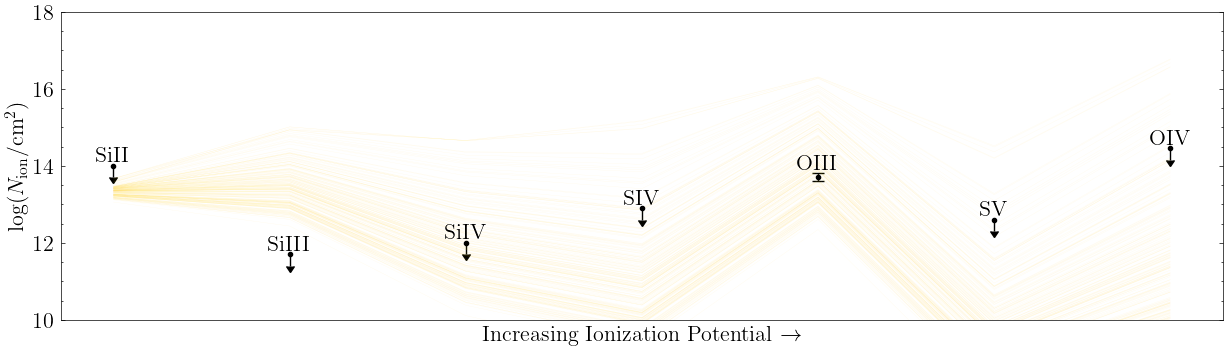

In [64]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [65]:
get_cloud_size(14.09, -1.2, species_logN_interp)

1.9440724316418225e-05

# c1 - Two-phase solution: simultaneous

In [66]:
def lambda_log_prior_two_phase(params):
    
    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, logN_HI_p2, log_hdens_p2, log_metals_p2 = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {}, logN_HI_p2, log_hdens_p2, log_metals_p2, {}])
    
    return log_prior_two_phase(params_full, species_logN_interp)

In [67]:
def lambda_log_likelihood_two_phase(params, logN_dict, species_logN_interp):

    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, logN_HI_p2, log_hdens_p2, log_metals_p2 = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {}, logN_HI_p2, log_hdens_p2, log_metals_p2, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood_two_phase(params_full, logN_dict, species_logN_interp)    

In [68]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior_two_phase(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood_two_phase(params, logN_dict, species_logN_interp)

Fit things

In [69]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            #'CII':'<13.4',
            #'CIII':'12.9, -0.2, +0.1',
            #'CIV':'13.65, -0.01, +0.01',
            #'NII':'<13.4',
            #'NIII':'<13.0',
            #'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            ##'AlII':'<11.0',
            ##'AlIII':'<11.4',
            'SiII':'<14.0',}
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',
            #'FeII':'<11.8',}

In [70]:
logN_HI_test = 14.09
log_hdens_test_p1 = -3.0
log_metals_test_p1 = 0.2

logN_HI_test_p2 = 13.9
log_hdens_test_p2 = -4.3
log_metals_test_p2 = 0.0

In [71]:
logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_test, log_hdens_test_p1, log_metals_test_p1, species_logN_interp))
logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_test_p2, log_hdens_test_p2, log_metals_test_p2, species_logN_interp))
logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

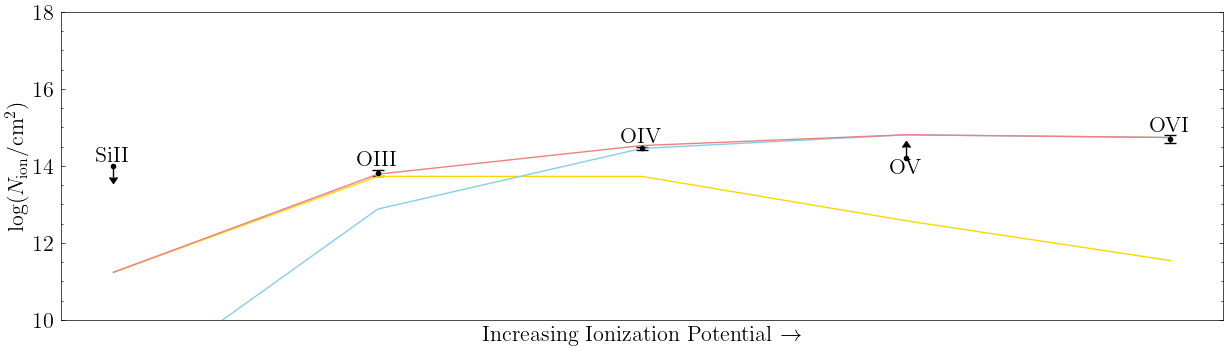

In [72]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test_p1)), logN_species_test_p1, color='gold')
ax.plot(np.arange(len(logN_species_test_p2)), logN_species_test_p2, color='skyblue')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral')

In [73]:
pos = np.array([log_hdens_test_p1, log_metals_test_p1, 
                logN_HI_test_p2, log_hdens_test_p2, log_metals_test_p2]) + 1e-4 * np.random.randn(200, 5)
nwalkers, ndim = pos.shape

In [74]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [75]:
#species_logN_interp['S+5']([16.67, 0.1, -0.6]), species_logN_interp['S+5']([14.9, -2.7, -1.0]), species_logN_interp['S+5']([14.9, -3.7, -1.0])

In [76]:
#sampler.run_mcmc(pos, 500, progress=True);

In [77]:
#flat_samples_two_phase = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens_p1', 'log_metals_p1', 
#                                         'logN_HI_p2', 'log_hdens_p2', 'log_metals_p2'])
#flat_samples_two_phase.to_csv(savedir+'two_phase_c1.csv', index=False)

flat_samples_two_phase = pd.read_csv(savedir+'two_phase_c1.csv')

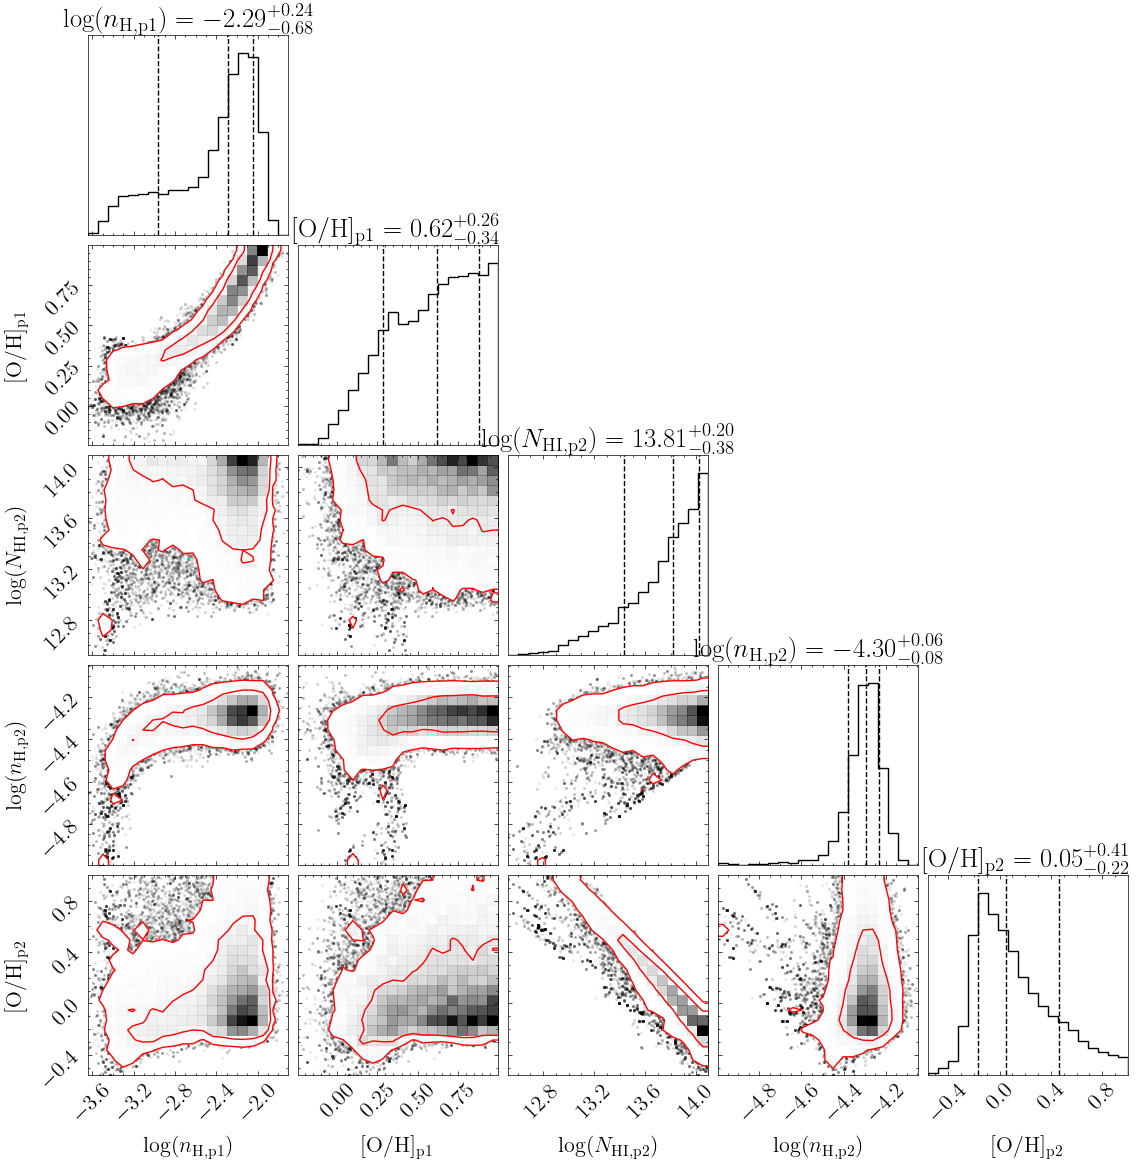

In [78]:
fig = corner.corner(
    flat_samples_two_phase, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H, p1})$', r'$[\mathrm{O/H}]_{\mathrm{p1}}$',
            r'$\log(N_\mathrm{HI, p2})$', r'$\log(n_\mathrm{H, p2})$', r'$[\mathrm{O/H}]_{\mathrm{p2}}$',], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [79]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.4',
            'NIII':'<13.0',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            'NeV':'14.17, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            ##'AlII':'<11.0',
            ##'AlIII':'<11.4',
            'SiII':'<14.0',}
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',
            #'FeII':'<11.8',}

In [80]:
sample_indices_two_phase = np.random.randint(low=0, high=len(flat_samples_two_phase), size=500)

(10.0, 16.0)

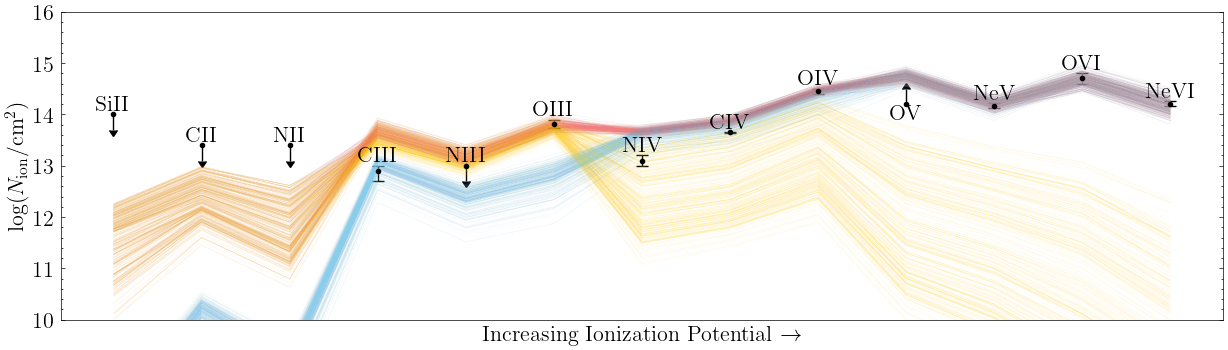

In [81]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_two_phase)):
    
    idx = sample_indices_two_phase[i]
    flat_samples_row = flat_samples_two_phase.iloc[i]
    
    log_hdens_p1 = flat_samples_row['log_hdens_p1']
    log_metals_p1 = flat_samples_row['log_metals_p1']
    
    logN_HI_p2 = flat_samples_row['logN_HI_p2']
    log_hdens_p2 = flat_samples_row['log_hdens_p2']
    log_metals_p2 = flat_samples_row['log_metals_p2']
    
    logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_test,  log_hdens_p1, log_metals_p1, species_logN_interp))
    logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_p2,  log_hdens_p2, log_metals_p2, species_logN_interp))

    logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.1)
    ax.plot(np.arange(len(logN_species_test_p1)), logN_species_test_p1, color='gold', lw=.2, alpha=.1)
    ax.plot(np.arange(len(logN_species_test_p2)), logN_species_test_p2, color='skyblue', lw=.2, alpha=.1)
    
ax.set_ylim(10,16)

# c1 - Two-phase solution: with relative abundances

In [14]:
def lambda_log_prior_two_phase(params):
    
    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, C_O_p1, N_O_p1, logN_HI_p2, log_hdens_p2, log_metals_p2, C_O_p2, N_O_p2 = params
    
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {'C': C_O_p1, 'N': N_O_p1},
                            logN_HI_p2, log_hdens_p2, log_metals_p2, {'C': C_O_p2, 'N': N_O_p2}])
    
    x = log_prior_two_phase(params_full, species_logN_interp)
    
    if np.isfinite(x):
        if log_hdens_p2 > -4.6:
            return x
        else:
            return -np.inf
    else:
        return -np.inf

In [15]:
def lambda_log_likelihood_two_phase(params, logN_dict, species_logN_interp):

    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, C_O_p1, N_O_p1, logN_HI_p2, log_hdens_p2, log_metals_p2, C_O_p2, N_O_p2 = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {'C': C_O_p1, 'N': N_O_p1},
                            logN_HI_p2, log_hdens_p2, log_metals_p2, {'C': C_O_p2, 'N': N_O_p2}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood_two_phase(params_full, logN_dict, species_logN_interp)    

In [16]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior_two_phase(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood_two_phase(params, logN_dict, species_logN_interp)

Fit things

In [21]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.4',
            'NIII':'<13.0',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            #'NeV':'14.17, -0.05, +0.05',
            #'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            'SiII':'<14.0',}
            #'SiIII':'<11.7',
            #'SiIV':'<12.0',
            #'SIV':'<12.9',
            #'SV':'<12.6',
            #'SVI':'<13.2',
            #'FeII':'<11.8',}

In [22]:
logN_HI_test = 14.09
log_hdens_test_p1 = -2.8
log_metals_test_p1 = 0.3
C_O_test_p1 = -0.9
N_O_test_p1 = -0.7

logN_HI_test_p2 = 14.0
log_hdens_test_p2 = -4.3
log_metals_test_p2 = -0.1
C_O_test_p2 = -0.3
N_O_test_p2 = -0.6

In [23]:
logN_species_test_p1 = np.array(predict_col_dens(logN_dict, 
                                                 logN_HI_test, 
                                                 log_hdens_test_p1, 
                                                 log_metals_test_p1, 
                                                 species_logN_interp,
                                                 {'C': C_O_test_p1, 'N': N_O_test_p1}))

logN_species_test_p2 = np.array(predict_col_dens(logN_dict, 
                                                 logN_HI_test_p2, 
                                                 log_hdens_test_p2, 
                                                 log_metals_test_p2, 
                                                 species_logN_interp,
                                                 {'C': C_O_test_p2, 'N': N_O_test_p2}))

logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

In [24]:
logN_species_test_p1[3], logN_species_test_p2[3]

(12.637295048289758, 12.790913827459583)

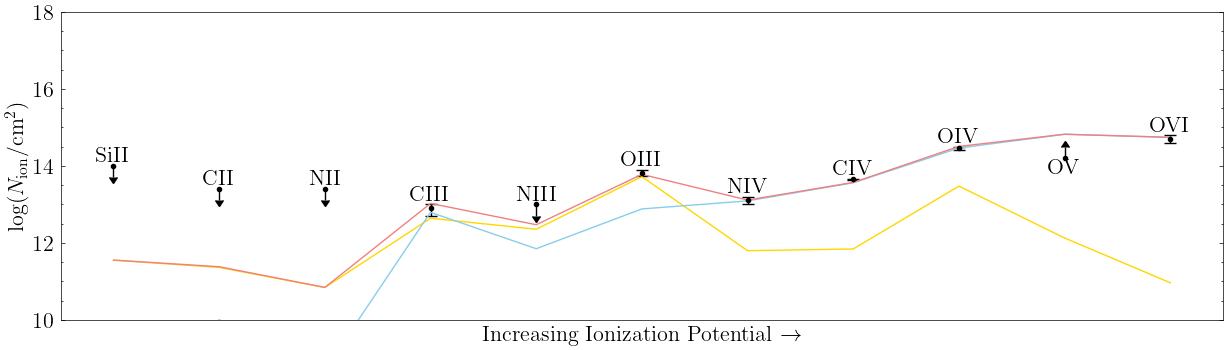

In [25]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test_p1)), logN_species_test_p1, color='gold')
ax.plot(np.arange(len(logN_species_test_p2)), logN_species_test_p2, color='skyblue')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral')

In [26]:
#log_hdens_test_p1, log_metals_test_p2, C_O_test_p1, N_O_test_p1, logN_HI_test_p2, log_hdens_test_p2, log_metals_test_p2, C_O_test_p2, N_O_test_p2

In [27]:
pos = np.array([log_hdens_test_p1, log_metals_test_p1, C_O_test_p1, N_O_test_p1,
                logN_HI_test_p2, log_hdens_test_p2, log_metals_test_p2, C_O_test_p2, N_O_test_p2]) + 1e-4 * np.random.randn(200, 9)
nwalkers, ndim = pos.shape

In [28]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [29]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [04:56<00:00,  1.69it/s]


In [30]:
flat_samples_two_phase = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens_p1', 'log_metals_p1', 'C_O_p1', 'N_O_p1', 
                                         'logN_HI_p2', 'log_hdens_p2', 'log_metals_p2', 'C_O_p2', 'N_O_p2'])
flat_samples_two_phase.to_csv(savedir+'two_phase_CN_c1.csv', index=False)

#flat_samples_two_phase = pd.read_csv(savedir+'two_phase_CN_c1.csv')

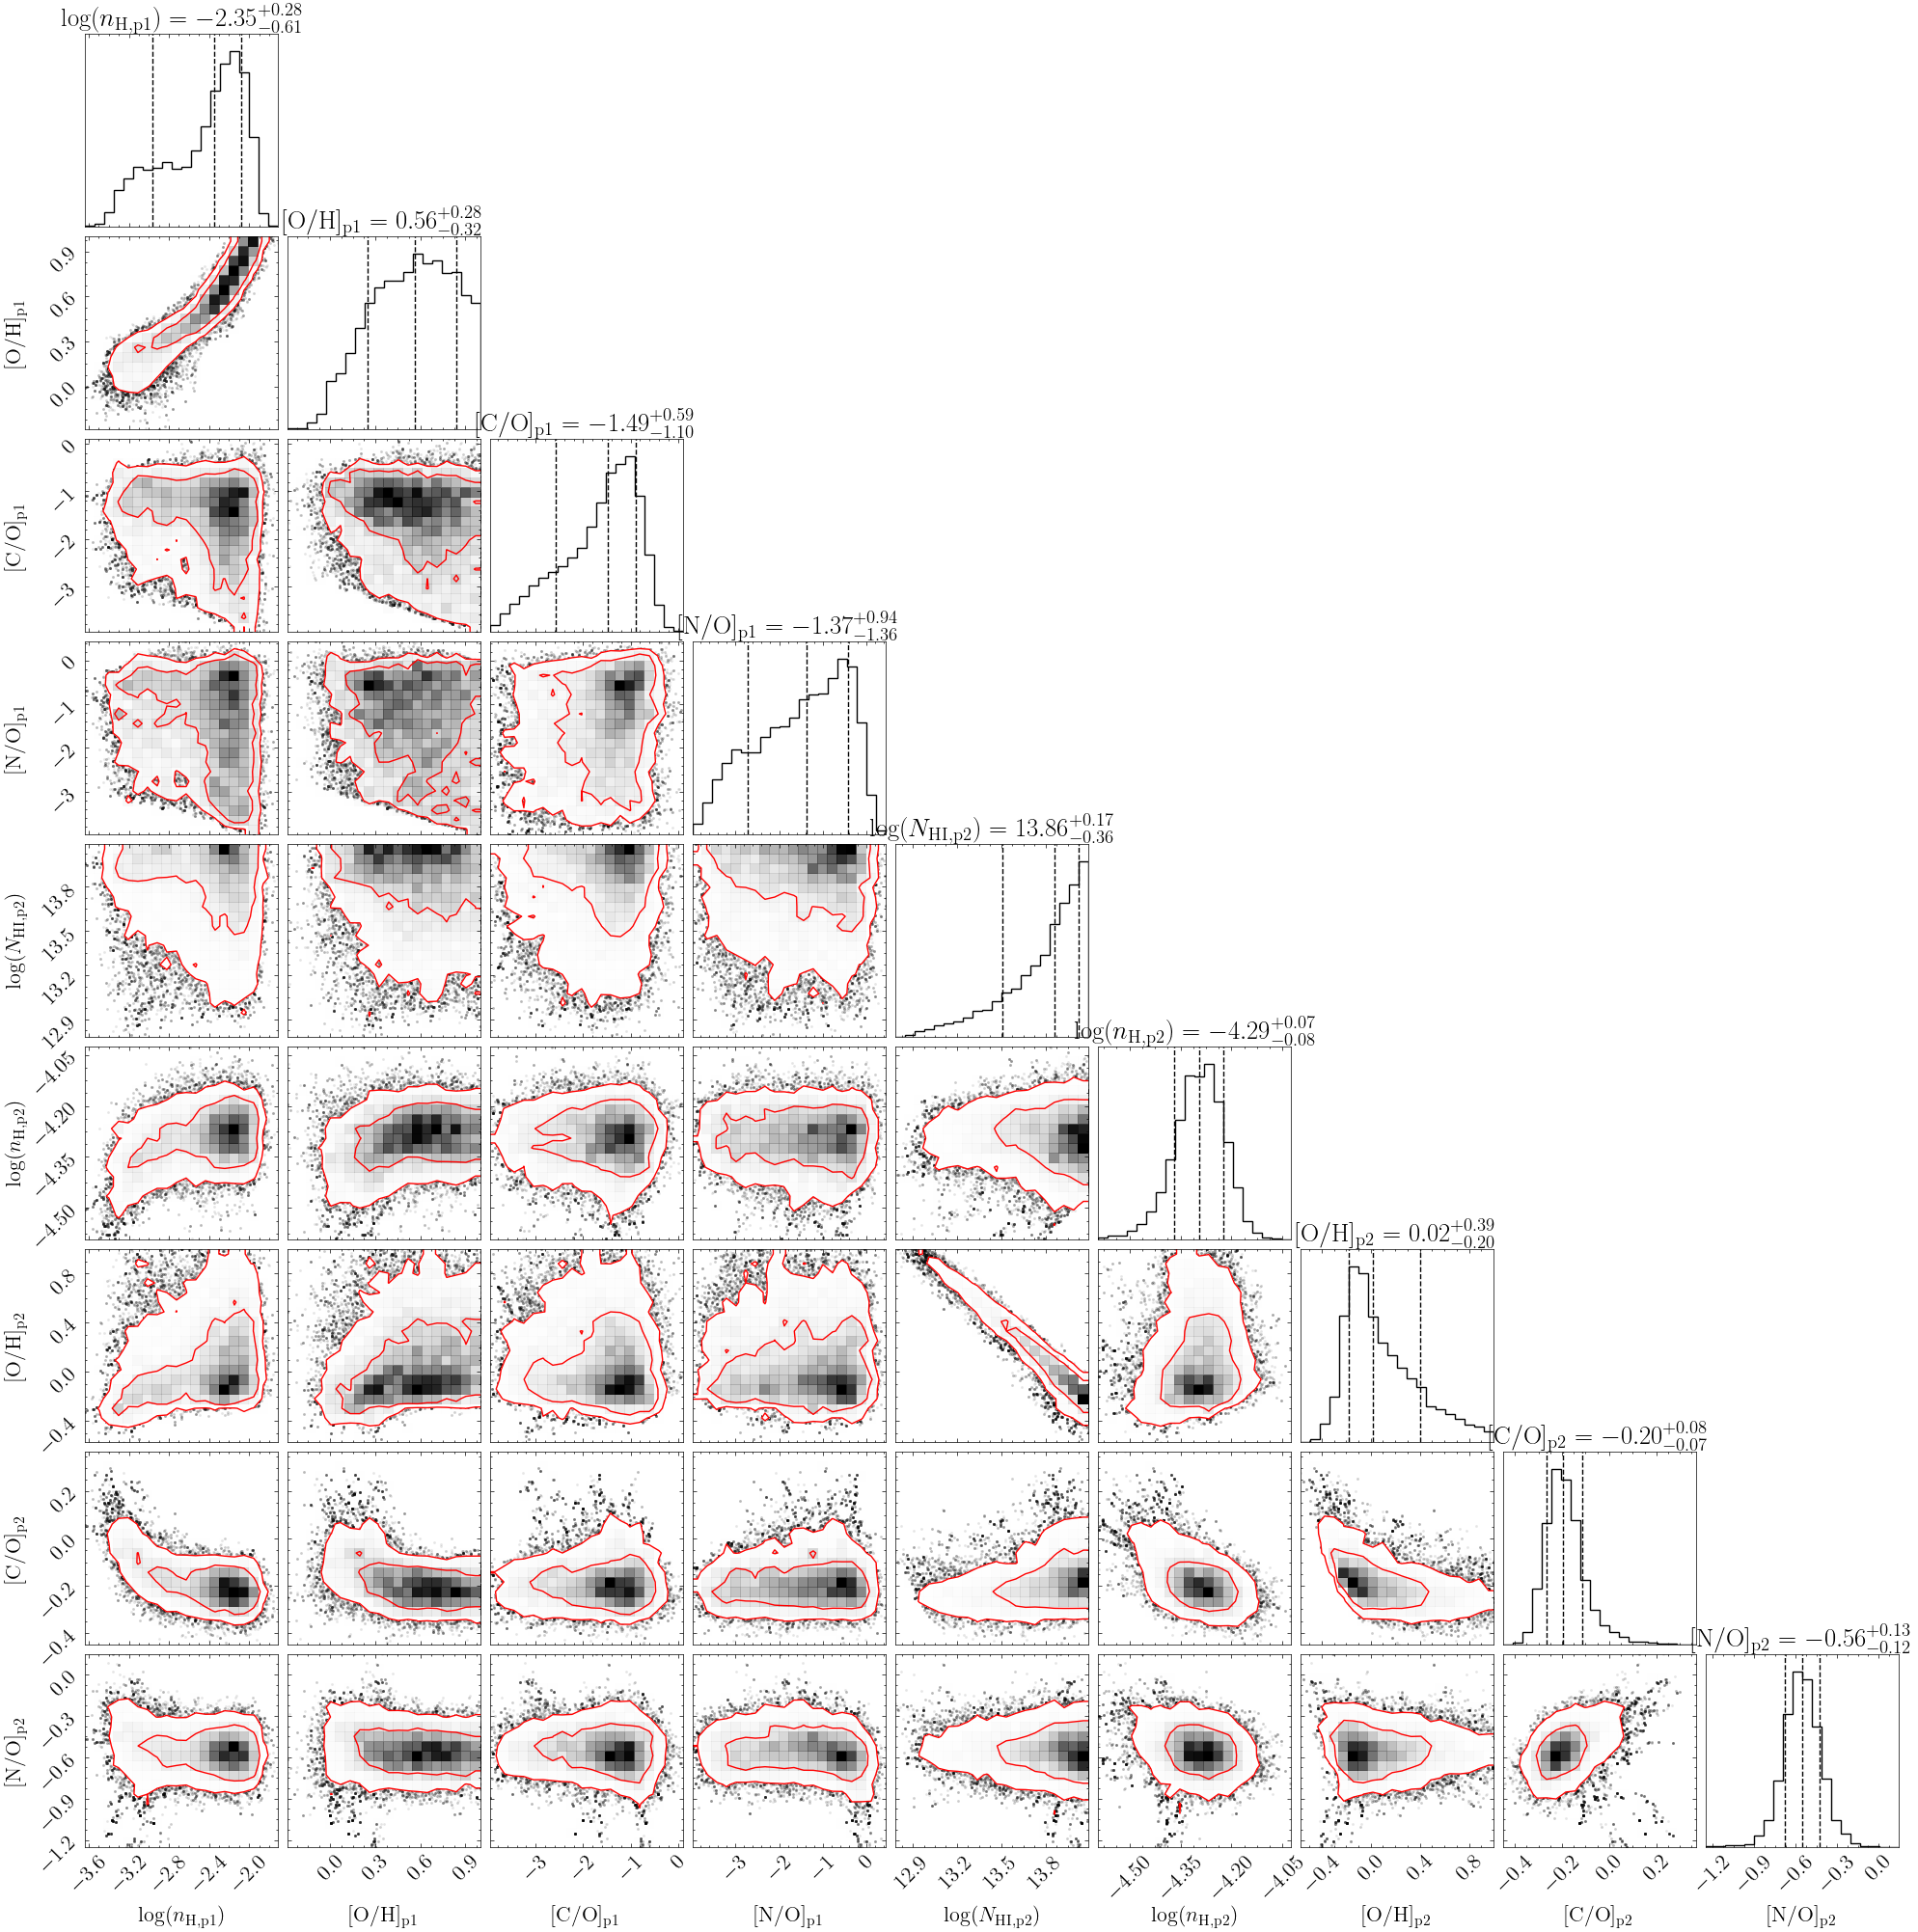

In [31]:
fig = corner.corner(
    flat_samples_two_phase, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H, p1})$', r'$[\mathrm{O/H}]_{\mathrm{p1}}$', r'$[\mathrm{C/O}]_{\mathrm{p1}}$', r'$[\mathrm{N/O}]_{\mathrm{p1}}$',
            r'$\log(N_\mathrm{HI, p2})$', r'$\log(n_\mathrm{H, p2})$', r'$[\mathrm{O/H}]_{\mathrm{p2}}$', r'$[\mathrm{C/O}]_{\mathrm{p2}}$', r'$[\mathrm{N/O}]_{\mathrm{p2}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [37]:
np.percentile(flat_samples_two_phase['log_hdens_p1'], 100*cdf_3sig)

-1.8370968260319882

In [38]:
np.percentile(flat_samples_two_phase['log_metals_p1'], 100*(1-cdf_3sig))

-0.13739614300323016

In [48]:
np.percentile(flat_samples_two_phase['C_O_p1'], 100*cdf_3sig)

-0.16364346488751486

In [49]:
np.percentile(flat_samples_two_phase['N_O_p1'], 100*cdf_3sig)

0.23366309699004575

Now plot the best models

In [41]:
logN_dict = {#'HI':'14.09, -0.06, +0.06',
            #'HeI':'<13.1',
            'CII':'<13.4',
            'CIII':'12.9, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.4',
            'NIII':'<13.0',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.82, -0.08, +0.08',
            'OIV':'14.45, -0.05, +0.05',
            'OV':'>14.2',
            'OVI':'14.7, -0.1, +0.1',
            'NeV':'14.17, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.6',
            #'MgX':'<13.6',
            #'AlII':'<11.0',
            #'AlIII':'<11.4',
            'SiII':'<14.0',
            'SiIII':'<11.7',
            'SiIV':'<12.0',
            'SIV':'<12.9',
            'SV':'<12.6',
            'SVI':'<13.2',}
            #'FeII':'<11.8',}

In [42]:
b_dict = {'HI':'24, -3, +3',
          'CIII':'11.1, -0.2, +0.2',
          'CIV':'11.1, -0.2, +0.2',
          'NIV':'12, -4, +5',
          'OIII':'12, -1, +1',
          'OIV':'12, -1, +1',
          'OV':'12, -1, +1',
          'OVI':'17, -2, +2',
          'NeV':'21, -4, +5',
          'NeVI':'21, -4, +4'}

In [43]:
sample_indices_two_phase = np.random.randint(low=0, high=len(flat_samples_two_phase), size=500)

In [44]:
z_sys = 1.27767328

In [45]:
import matplotlib.lines as mlines

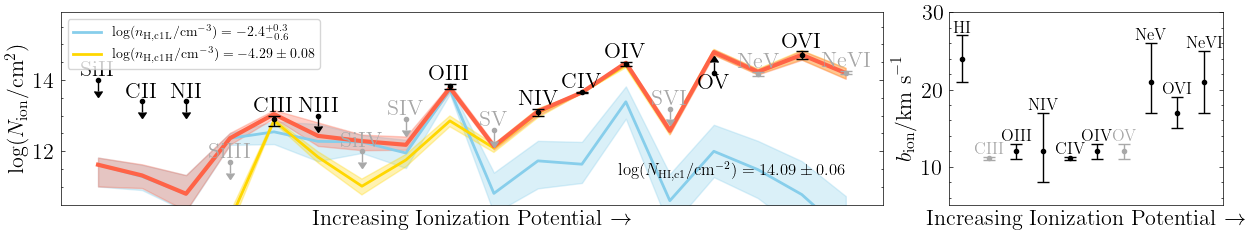

In [46]:
logN_species_p1_grid = np.zeros((len(logN_dict), len(sample_indices_two_phase)))
logN_species_p2_grid = np.zeros((len(logN_dict), len(sample_indices_two_phase)))
logN_species_grid = np.zeros((len(logN_dict), len(sample_indices_two_phase)))

fig, axes = plt.subplots(1, 2, figsize=(15,2.5), gridspec_kw={'width_ratios': [3, 1]})

for i in range(len(sample_indices_two_phase)):
    
    idx = sample_indices_two_phase[i]
    flat_samples_row = flat_samples_two_phase.iloc[i]
    
    log_hdens_p1 = flat_samples_row['log_hdens_p1']
    log_metals_p1 = flat_samples_row['log_metals_p1']
    C_O_p1 = flat_samples_row['C_O_p1']
    N_O_p1 = flat_samples_row['N_O_p1']
    
    logN_HI_p2 = flat_samples_row['logN_HI_p2']
    log_hdens_p2 = flat_samples_row['log_hdens_p2']
    log_metals_p2 = flat_samples_row['log_metals_p2']
    C_O_p2 = flat_samples_row['C_O_p2']
    N_O_p2 = flat_samples_row['N_O_p2']
    
    logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_test,  log_hdens_p1, log_metals_p1, 
                                                     species_logN_interp,{'C':C_O_p1,
                                                                          'N':N_O_p1}))
    logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_p2,  log_hdens_p2, log_metals_p2, 
                                                     species_logN_interp, {'C':C_O_p2,
                                                                           'N':N_O_p2}))

    logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)
    
    logN_species_p1_grid[:,i] = logN_species_test_p1
    logN_species_p2_grid[:,i] = logN_species_test_p2
    logN_species_grid[:,i] = logN_species_test
    
logN_species_p1_med = np.median(logN_species_p1_grid, axis=1)
logN_species_p1_lo = np.percentile(logN_species_p1_grid, 100*(1-cdf_1sig), axis=1)
logN_species_p1_hi = np.percentile(logN_species_p1_grid, 100*cdf_1sig, axis=1)

logN_species_p2_med = np.median(logN_species_p2_grid, axis=1)
logN_species_p2_lo = np.percentile(logN_species_p2_grid, 100*(1-cdf_1sig), axis=1)
logN_species_p2_hi = np.percentile(logN_species_p2_grid, 100*cdf_1sig, axis=1)

logN_species_med = np.median(logN_species_grid, axis=1)
logN_species_lo = np.percentile(logN_species_grid, 100*(1-cdf_1sig), axis=1)
logN_species_hi = np.percentile(logN_species_grid, 100*cdf_1sig, axis=1)

axes[0].fill_between(np.arange(len(logN_species_test)), logN_species_p1_lo, logN_species_p1_hi,
                color='skyblue', alpha=.3)
axes[0].plot(np.arange(len(logN_species_test)), logN_species_p1_med, color='skyblue', lw=2, alpha=1)

axes[0].fill_between(np.arange(len(logN_species_test)), logN_species_p2_lo, logN_species_p2_hi,
                color='gold', alpha=.3)
axes[0].plot(np.arange(len(logN_species_test)), logN_species_p2_med, color='gold', lw=2, alpha=1)

axes[0].fill_between(np.arange(len(logN_species_test)), logN_species_lo, logN_species_hi,
                color='tomato', alpha=.3)
axes[0].plot(np.arange(len(logN_species_test)), logN_species_med, color='tomato', lw=3, alpha=1)

    
plot_column_densities_obs(logN_dict, fig, axes[0],
                          gray_out = ['NeV', 'NeVI', 'SiIII', 'SiIV', 'SIV', 'SV', 'SVI'])

axes[0].set_ylim(10.5,15.9)

axes[0].text(len(logN_dict)-1, 11.3, r'$\log(N_\mathrm{HI, c1}/\mathrm{cm}^{-2}) = 14.09 \pm 0.06$', fontsize=12,
            horizontalalignment='right')

handles = []

handles.append(mlines.Line2D([], [], lw=2,
                             color='skyblue', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H, c1L}/\mathrm{cm}^{-3}) = -2.4_{-0.6}^{+0.3}$'))

handles.append(mlines.Line2D([], [], lw=2,
                             color='gold', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H, c1H}/\mathrm{cm}^{-3}) = -4.29 \pm 0.08$'))
    
axes[0].legend(handles=handles, loc='upper left', fontsize=10)

plt.subplots_adjust(wspace=0.12, hspace=0)   

plot_linewidth_obs(b_dict, fig, axes[1], fs=12, gray_out=['CIII','OV'])
axes[1].set_xlim(-0.5, len(b_dict)-1+.7)
axes[1].set_ylim(5.1,30)
#ax.set_title('Two-phase decomposition for a CIV absorber', fontsize=18)

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_cloudy_c1.pdf'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)

Get cloud sizes

In [50]:
l_p1 = np.zeros(len(flat_samples_two_phase))
l_p2 = np.zeros(len(flat_samples_two_phase))

In [51]:
for i in range(len(l_p1)):
    
    flat_samples_row = flat_samples_two_phase.iloc[i]
    
    l_p1[i] = get_cloud_size(logN_HI_test, flat_samples_row['log_hdens_p1'], species_logN_interp)
    l_p2[i] = get_cloud_size(flat_samples_row['logN_HI_p2'], flat_samples_row['log_hdens_p2'], species_logN_interp)

Text(0, 0.5, 'Counts')

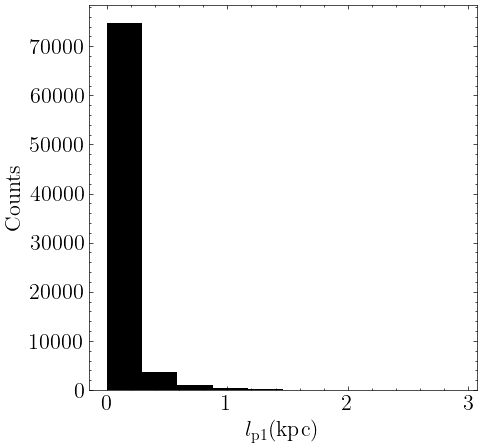

In [52]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_p1, bins=10)

ax.set_xlabel(r'$l_{\mathrm{p1}} (\mathrm{kpc})$')
ax.set_ylabel('Counts')

In [54]:
np.median(l_p1), np.percentile(l_p1, 100*cdf_3sig)

(0.004811771709922713, 1.3361317996483417)

Text(0, 0.5, 'Counts')

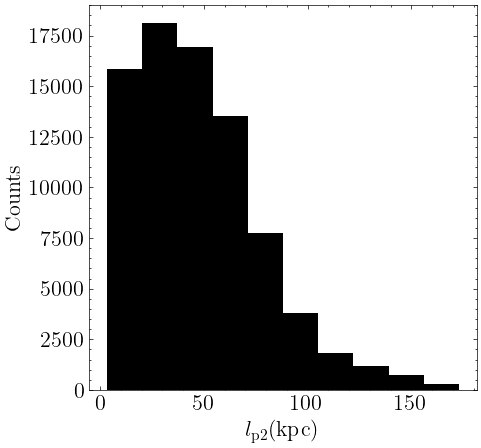

In [53]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_p2, bins=10)

ax.set_xlabel(r'$l_{\mathrm{p2}} (\mathrm{kpc})$')
ax.set_ylabel('Counts')

In [55]:
np.median(l_p2), np.percentile(l_p2, 100*cdf_3sig)

(43.417156439168664, 160.7042093744342)

# c2 - First look

Enter measurements for species

In [133]:
logN_dict = {'HI':'13.99, -0.07, +0.07',
        'HeI':'<13.1',
        'CII':'<13.4',
        'CIII':'<12.7',
        'CIV':'13.41, -0.01, +0.01',
        'NII':'<13.4',
        'NIII':'<13.0',
        'NIV':'<12.7',
        'OIII':'<13.4',
        'OIV':'14.22, -0.06, +0.06',
        'OV':'>14.2',
        'OVI':'14.0, -0.1, +0.1',
        'NeV':'13.7, -0.1, +0.1',
        'NeVI':'13.97, -0.08, +0.08',
        'NeVIII':'<13.6',
        'MgX':'<13.6',
        'AlII':'<11.0',
        'AlIII':'<11.4',
        'SiII':'<14.0',
        'SiIII':'<11.7',
        'SiIV':'<12.0',
        'SIV':'<12.9',
        'SV':'<12.6',
        'SVI':'<13.2',
        'FeII':'<11.8'}

Try out a solution

In [134]:
logN_HI_test = 13.99
log_hdens_test = -3.67
log_metals_test = -0.29

In [135]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

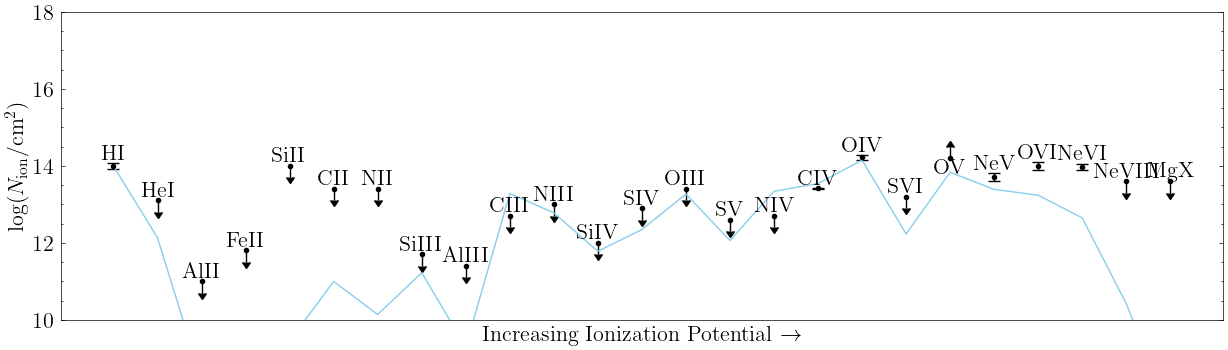

In [136]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='skyblue')

# c2 - Two-phase solution: low density phase

In [137]:
logN_dict = {#'HI':'13.99, -0.07, +0.07',
        #'HeI':'<13.1',
        #'CII':'<13.4',
        #'CIII':'<12.7',
        #'CIV':'13.41, -0.01, +0.01',
        #'NII':'<13.4',
        #'NIII':'<13.0',
        #'NIV':'<12.7',
        'OIII':'<13.4',
        'OIV':'14.22, -0.06, +0.06',
        'OV':'>14.2',
        'OVI':'14.0, -0.1, +0.1',}
        #'NeV':'13.7, -0.1, +0.1',
        #'NeVI':'13.97, -0.08, +0.08',
        #'NeVIII':'<13.6',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.4',
        #'SiII':'<14.0',
        #'SiIII':'<11.7',
        #'SiIV':'<12.0',
        #'SIV':'<12.9',
        #'SV':'<12.6',
        #'SVI':'<13.2',
        #'FeII':'<11.8'}

Get column density ratios

In [140]:
gen_logN_ratio_str(logN_dict['OIII'], logN_dict['OIV'])

'<-0.82, 0.15'

In [141]:
logN_ratio_dict = {'OVI/OIV':'-0.2, -0.1, 0.1',
                   'OV/OIV': '>-0.0, 0.3',
                   'OIII/OIV':'<-0.8, 0.2'}

(-2.2, 2.0)

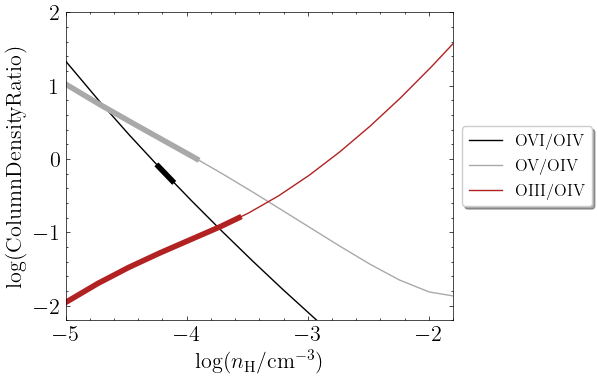

In [142]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2)

In [146]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [147]:
pos = np.array(-4.2) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [148]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [151]:
#sampler.run_mcmc(pos, 500, progress=True);

In [154]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo_c2.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo_c2.csv')

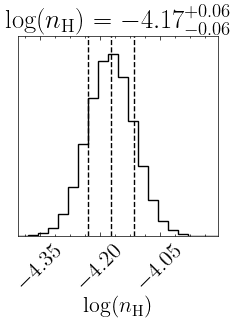

In [155]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [156]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [157]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

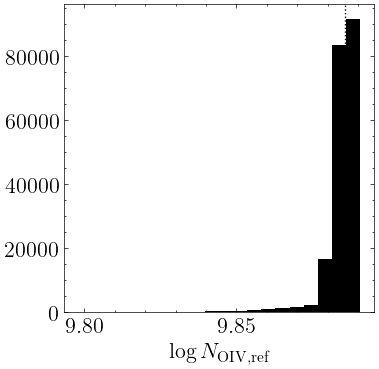

In [158]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [159]:
logN_offset = 14.22-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [160]:
logN_offset

4.334373130311752

Calculate the C/O ratio

In [161]:
logN_CIV_obs = np.random.normal(loc=13.41, scale=0.01, size=len(flat_samples_hdens))

In [162]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [163]:
get_quantiles(C_O_dist)

0.12 -0.01 0.01


Plot models

In [164]:
logN_dict = {#'HI':'13.99, -0.07, +0.07',
        #'HeI':'<13.1',
        #'CII':'<13.4',
        'CIII':'<12.7',
        'CIV':'13.41, -0.01, +0.01',
        #'NII':'<13.4',
        #'NIII':'<13.0',
        #'NIV':'<12.7',
        'OIII':'<13.4',
        'OIV':'14.22, -0.06, +0.06',
        'OV':'>14.2',
        'OVI':'14.0, -0.1, +0.1',
        'NeV':'13.7, -0.1, +0.1',
        'NeVI':'13.97, -0.08, +0.08',
        #'NeVIII':'<13.6',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.4',
        'SiII':'<14.0',}
        #'SiIII':'<11.7',
        #'SiIV':'<12.0',
        #'SIV':'<12.9',
        #'SV':'<12.6',
        #'SVI':'<13.2',
        #'FeII':'<11.8'}

In [165]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

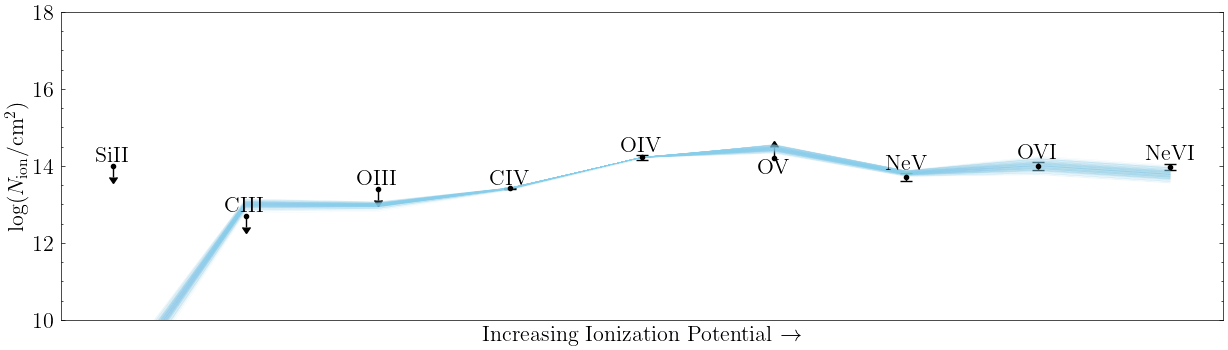

In [166]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

# c2 - Single phase solution: with relative abundances

In [56]:
def lambda_log_prior(params):
    
    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, C_O = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {'C':C_O}])
    
    return log_prior(params_full)

In [57]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Grid parameters being varied
    log_hdens_p1, log_metals_p1, C_O = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    params_full = np.array([logN_HI_test, log_hdens_p1, log_metals_p1, {'C':C_O}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [58]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

In [59]:
logN_dict = {#'HI':'13.99, -0.07, +0.07',
        #'HeI':'<13.1',
        'CII':'<13.4',
        'CIII':'<12.7',
        'CIV':'13.41, -0.01, +0.01',
        #'NII':'<13.4',
        #'NIII':'<13.0',
        #'NIV':'<12.7',
        'OIII':'<13.4',
        'OIV':'14.22, -0.06, +0.06',
        'OV':'>14.2',
        'OVI':'14.0, -0.1, +0.1',
        #'NeV':'13.7, -0.1, +0.1',
        #'NeVI':'13.97, -0.08, +0.08',
        #'NeVIII':'<13.6',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.4',
        'SiII':'<14.0',}
        #'SiIII':'<11.7',
        #'SiIV':'<12.0',
        #'SIV':'<12.9',
        #'SV':'<12.6',
        #'SVI':'<13.2',
        #'FeII':'<11.8'}

In [60]:
logN_HI_test = 13.99
log_hdens_test = -4.0
log_metals_test = -0.4
C_O_test = -0.15

In [61]:
#species_logN_interp['Si+2']([logN_HI_test, log_hdens_test_p1, log_metals_test_p1])[0]

In [62]:
logN_species_test = np.array(predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, log_metals_test, species_logN_interp, {'C':C_O_test}))

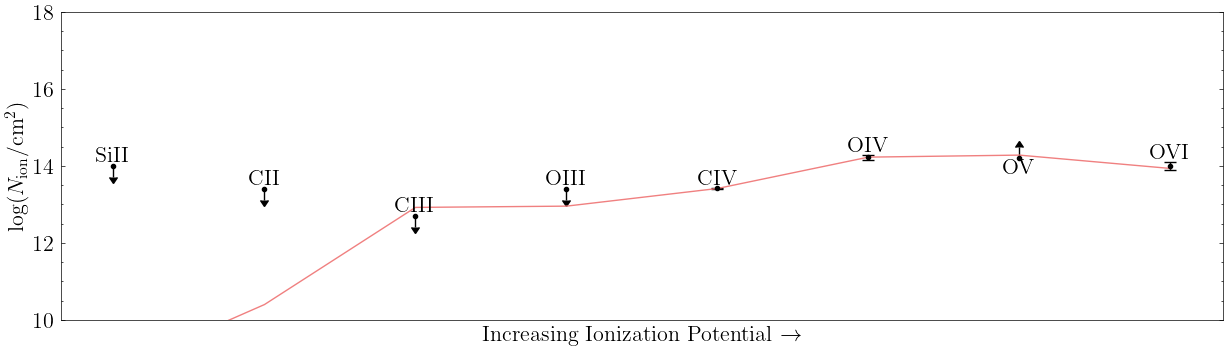

In [63]:
fig, ax = plot_column_densities_obs(logN_dict)
#ax.plot(np.arange(len(logN_species_test_p1)), logN_species_test_p1, color='skyblue')
#ax.plot(np.arange(len(logN_species_test_p2)), logN_species_test_p2, color='gold')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral')

In [64]:
pos = np.array([log_hdens_test, log_metals_test, C_O_test]) + 1e-7 * np.random.randn(200, 3)
nwalkers, ndim = pos.shape

In [65]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [66]:
#species_logN_interp['S+5']([16.67, 0.1, -0.6]), species_logN_interp['S+5']([14.9, -2.7, -1.0]), species_logN_interp['S+5']([14.9, -3.7, -1.0])

In [71]:
#sampler.run_mcmc(pos, 500, progress=True);

In [72]:
#flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens', 'log_metals', 'C_O'])
#flat_samples.to_csv(savedir+'one_phase_c2.csv', index=False)

flat_samples = pd.read_csv(savedir+'one_phase_c2.csv')

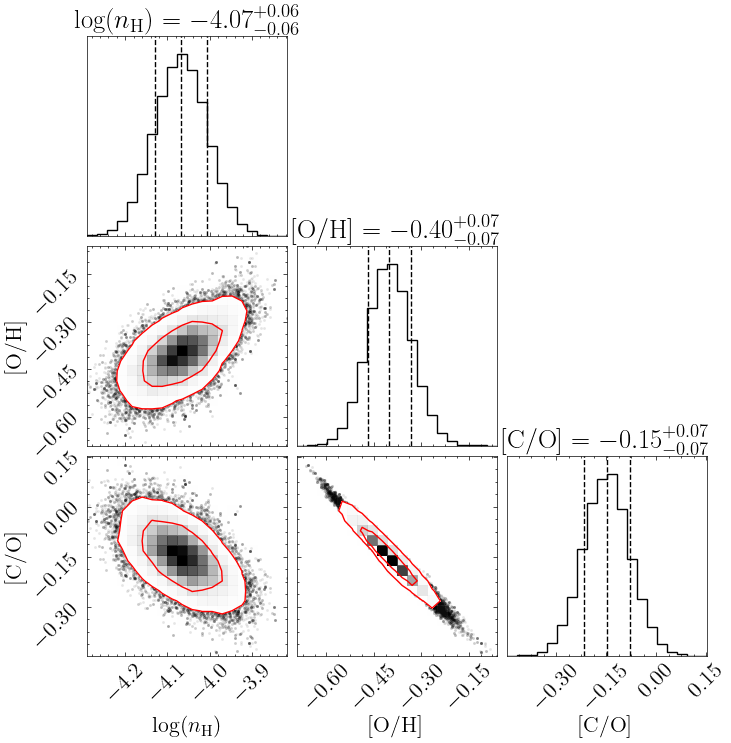

In [73]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$', r'$[\mathrm{C/O}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [86]:
logN_dict = {#'HI':'13.99, -0.07, +0.07',
        #'HeI':'<13.1',
        'CII':'<13.4',
        'CIII':'<12.7',
        'CIV':'13.41, -0.01, +0.01',
        'NII':'<13.4',
        'NIII':'<13.0',
        'NIV':'<12.7',
        'OIII':'<13.4',
        'OIV':'14.22, -0.06, +0.06',
        'OV':'>14.2',
        'OVI':'14.0, -0.1, +0.1',
        'NeV':'13.7, -0.1, +0.1',
        'NeVI':'13.97, -0.08, +0.08',
        #'NeVIII':'<13.6',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.4',
        'SiII':'<14.0',
        'SiIII':'<11.7',
        'SiIV':'<12.0',
        'SIV':'<12.9',
        'SV':'<12.6',
        'SVI':'<13.2',}
        #'FeII':'<11.8'}

In [87]:
b_dict = {'HI':'37, -10, +10',
          'CIV': '9.8, -0.3, +0.3',
          'OIV': '10, -1, +2',
          'OV': '10, -1, +2',
          'OVI': '14, -3, +4',
          'NeV': '15, -6, +7',
          'NeVI': '21, -5, +6'}

In [88]:
sample_indices_one_phase = np.random.randint(low=0, high=len(flat_samples), size=500)

In [89]:
z_sys = 1.27767328

In [90]:
import matplotlib.lines as mlines

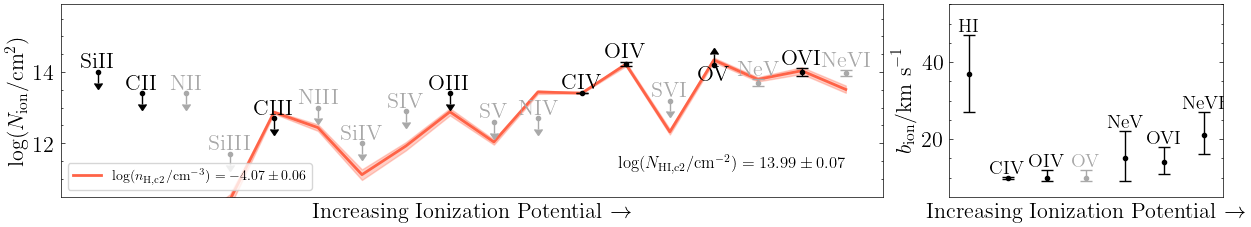

In [91]:
logN_species_grid = np.zeros((len(logN_dict), len(sample_indices_one_phase)))

fig, axes = plt.subplots(1, 2, figsize=(15,2.5), gridspec_kw={'width_ratios': [3, 1]})

for i in range(len(sample_indices_one_phase)):
    
    idx = sample_indices_one_phase[i]
    flat_samples_row = flat_samples.iloc[i]
    
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    C_O = flat_samples_row['C_O']
    
    logN_species_test = np.array(predict_col_dens(logN_dict, logN_HI_test,  log_hdens, log_metals, 
                                                     species_logN_interp,{'C':C_O}))

    logN_species_grid[:,i] = logN_species_test
    
logN_species_med = np.median(logN_species_grid, axis=1)
logN_species_lo = np.percentile(logN_species_grid, 100*(1-cdf_1sig), axis=1)
logN_species_hi = np.percentile(logN_species_grid, 100*cdf_1sig, axis=1)

axes[0].fill_between(np.arange(len(logN_species_test)), logN_species_lo, logN_species_hi,
                color='tomato', alpha=.3)
axes[0].plot(np.arange(len(logN_species_test)), logN_species_med, color='tomato', lw=2, alpha=1)

    
plot_column_densities_obs(logN_dict, fig, axes[0],
                          gray_out = ['NeV', 'NeVI', 'SiIII', 'SiIV', 'SIV', 'SV', 'SVI', 'NII', 'NIII', 'NIV'])

axes[0].set_ylim(10.5,15.9)

axes[0].text(len(logN_dict)-1, 11.3, r'$\log(N_\mathrm{HI, c2}/\mathrm{cm}^{-2}) = 13.99 \pm 0.07$', fontsize=12,
            horizontalalignment='right')

handles = []

handles.append(mlines.Line2D([], [], lw=2,
                             color='tomato', 
                             marker='None',
              linestyle='-', markersize=8, label=r'$\log(n_\mathrm{H, c2}/\mathrm{cm}^{-3}) = -4.07 \pm 0.06$'))

axes[0].legend(handles=handles, loc='lower left', fontsize=10)

plt.subplots_adjust(wspace=0.12, hspace=0)   

plot_linewidth_obs(b_dict, fig, axes[1], fs=14, gray_out = ['OV'])
axes[1].set_xlim(-0.5, len(b_dict)-1+0.5)
axes[1].set_ylim(5,55)
#ax.set_title('Two-phase decomposition for a CIV absorber', fontsize=18)

plt.savefig('/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z={}/z={}_cloudy_c2.pdf'.format(z_sys, str(z_sys).replace('.', '_')), dpi=150)

Get cloud sizes

In [81]:
l = np.zeros(len(flat_samples))

In [82]:
for i in range(len(l)):
    
    flat_samples_row = flat_samples.iloc[i]
    
    l[i] = get_cloud_size(logN_HI_test, flat_samples_row['log_hdens'], species_logN_interp)

Text(0, 0.5, 'Counts')

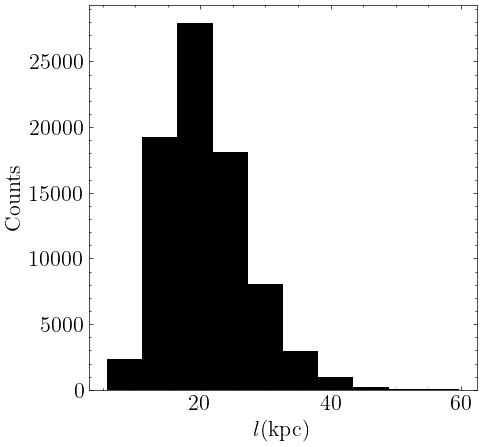

In [83]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l, bins=10)

ax.set_xlabel(r'$l (\mathrm{kpc})$')
ax.set_ylabel('Counts')

In [85]:
np.median(l), np.median(l)-np.percentile(l, 100*(1-cdf_1sig)), np.percentile(l, 100*cdf_1sig)-np.median(l)

(19.93149128574779, 5.258829583787529, 7.201175263760735)

# DRAFT

# c1 - Single phase solution

In [18]:
gen_logN_ratio_str(logN_dict['OIV'], logN_dict['OIII'])

'0.59, -0.09, 0.09'

In [19]:
logN_ratio_dict = {'OIV/OIII': '0.59, -0.09, 0.09'}
                   #'SIV/OIII': '<-1.2, 0.2',
                   #'SV/OIII': '<-1.5, 0.2'}

(-2.2, 2.5)

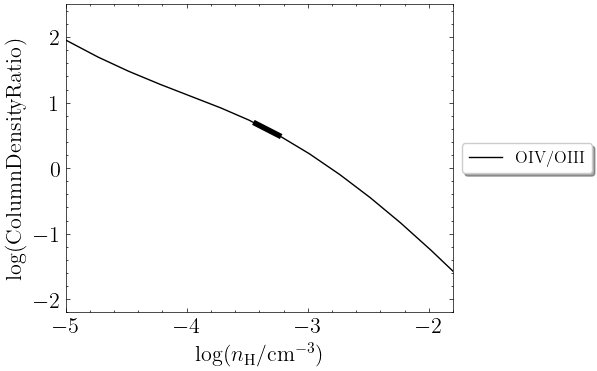

In [20]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.8)
ax.set_ylim(-2.2, 2.5)

In [21]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [22]:
pos = np.array(-3.3) + 1e-4 * np.random.randn(200, 1)
nwalkers, ndim = pos.shape

In [23]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [24]:
#sampler.run_mcmc(pos, 500, progress=True);

In [25]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])
#
#flat_samples_hdens.to_csv(savedir+'hdens_op.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_op.csv')

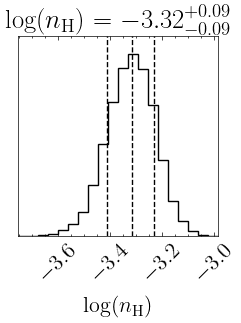

In [26]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [27]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [28]:
logN_offset = 13.85-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate C/O ratio

In [29]:
logN_CIV_obs = np.random.normal(loc=13.65, scale=0.01, size=len(flat_samples_hdens))

In [30]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [31]:
get_quantiles(C_O_dist)

0.0 -0.11 0.11


Calculate the N/O ratio

In [32]:
logN_NIV_obs = np.random.normal(loc=13.1, scale=0.1, size=len(flat_samples_hdens))

In [33]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [34]:
get_quantiles(N_O_dist)

-0.5 -0.16 0.16


Get yields

In [35]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

13.85 -0.02 0.01


Plot models

In [36]:
logN_dict = {#'HI':'14.08, -0.06, +0.06',
            'HeI':'<12.7',
            'CII':'<13.1',
            'CIII':'13.0, -0.2, +0.1',
            'CIV':'13.65, -0.01, +0.01',
            'NII':'<13.1',
            'NIII':'<12.8',
            'NIV':'13.1, -0.1, +0.1',
            'OIII':'13.85, -0.08, +0.08',
            'OIV':'14.44, -0.05, +0.05',
            'OV':'14.22, -0.05, +0.05',
            'OVI':'14.64, -0.07, +0.09',
            'NeV':'14.18, -0.05, +0.05',
            'NeVI':'14.21, -0.05, +0.05',
            #'NeVIII':'<13.3',
            #'MgX':'<13.4',
            'AlII':'<10.7',
            'AlIII':'<11.2',
            'SiII':'<13.9',
            'SiIII':'<11.7',
            'SiIV':'<11.7',
            'SIV':'<12.6',
            'SV':'<12.3',
            'SVI':'<12.9'}

In [37]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

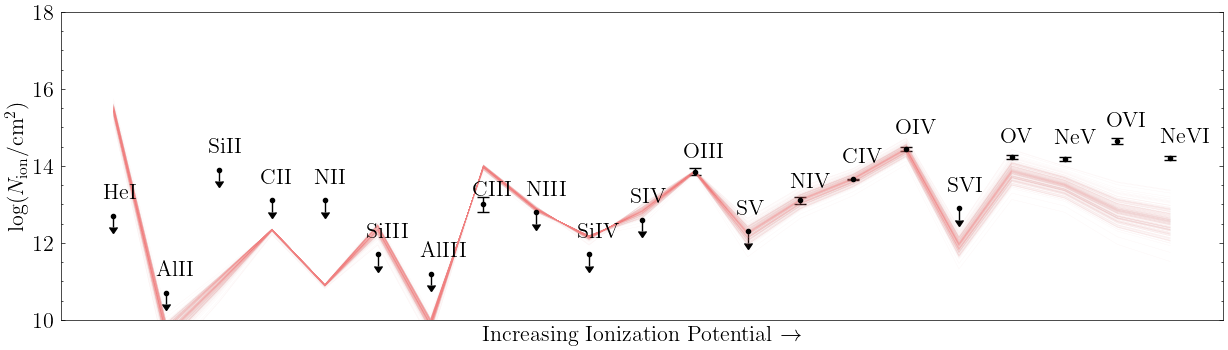

In [38]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp, {'C': np.median(C_O_dist), 'N': np.median(N_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)